In [22]:
import sys
import torch
import matplotlib.pyplot as plt
import numpy as np
from architecture.session_bigdata import Session, egeofno_ver1, egeofno_ver2, \
    egeofno_ver3, egeofno_ver4, svdfno_ver1, svdfno_ver2, svdfno_ver3, svdfno_ver4, fno_ver3


######### FIX MATRIX PLOTTING TAMALE #####
N_train = 40000
data_dir = "/home/emastr/deep-micro-slip-model/data/micro_geometries_boundcurv_repar_256_torch/data_0.torch"
save_dir = "/mnt/data0/emastr/article_training_hugedata/"
fig_dir = "/home/emastr/deep-micro-slip-model/data/"

device = "cuda:1"

option=2
if option == 1:
    name = "fno_ver1"
    label = "Geo FNO"
    net_gen = egeofno_ver1
else:
    name = "fno_vanilla_ver3"
    label = "Vanilla FNO"
    net_gen = fno_ver3
    
colors = ["steelblue", "indianred"]

def load_nets():
    nets = []
    #plt.figure(figsize=(8,8))
    for seed in [0, 1, 2, 3, 4, 5]:#, 4, 5]:
        #save_name = f"svdfno_ver{idx}_seed{seed}"
        save_name = f"{name}_seed{seed}"
        save = torch.load(f"{save_dir}{save_name}_{N_train}.Torch")
        state_dict = save["state dict"]
        net_settings = save["settings"]
        net = net_gen(device=device)
        net.load_state_dict(state_dict)
        nets.append(net)
    return nets, net_settings
    
nets, net_settings = load_nets()
net_settings["device"] = device
net_settings["num_pts"] = 256
net_settings["dtype"] = torch.float32

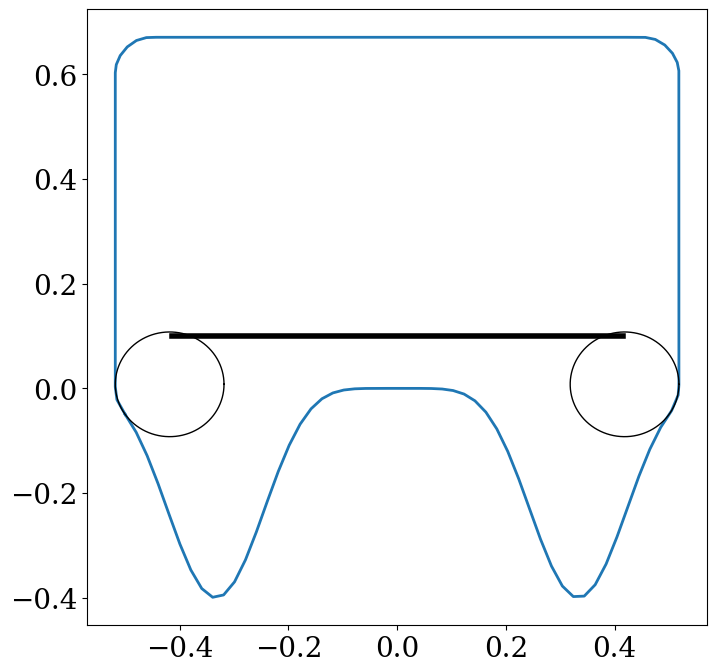

In [23]:
from boundary_solvers.geometry_torch import geometry_to_net_input, unpack, GeomData, concat_dict_entries, subdict, projection
from boundary_solvers.geometry import RoundedMicroGeomGenericV2, RoundedMicroGeomV2


_2np = lambda x: x.cpu().detach().numpy()

eps = 0.2
k = 3.0/0.5
shift = 0.0*np.pi
kx = 4.0/0.5
epsx = 0.1
func1 = lambda x: x/(0.5*np.pi) - 0.5 - 1j*((1.+np.cos(x*k)))*eps + np.sin((x+shift)*kx)*epsx
dfunc1 = lambda x: 1/(0.5*np.pi) + 1j*k*np.sin(x*k)*eps + kx*np.cos((x+shift)*kx)*epsx
ddfunc1 = lambda x: 0.*x + 1j*k**2*np.cos(x*k)*eps - kx**2*np.sin((x+shift)*kx)*epsx


#func = lambda x: x/(0.5*np.pi) - 0.5 + 1j*(-1.0-np.cos(x*k))*eps
#dfunc = lambda x: 1/(0.5*np.pi) + 1j*k*np.sin(x*k)*eps
#ddfunc = lambda x: 0.*x + 1j*k**2*np.cos(x*k)*eps

eps2 = 0.05
k2 = 3.0/0.5
func2 = lambda x: x/(0.5*np.pi) - 0.5 - 1j*((1.+np.sin(x*k2))**3)*eps2
dfunc2 = lambda x: 1/(0.5*np.pi) - 1j*3*eps2*k2*np.cos(x*k2)*(1.+np.sin(x*k2))**2
ddfunc2 = lambda x: 0.*x - 1j*3*eps2*k2*(-k2*np.sin(x*k2)*(1.+np.sin(x*k2))**2 + 2*(k2*np.cos(x*k2))*(1.+np.sin(x*k2))**1)

func3 = lambda x: x/(0.5*np.pi) - 0.5 - 1j*((1.+np.cos(x*k)))*eps + np.sin((x+shift)*kx)*epsx
dfunc3 = lambda x: 1/(0.5*np.pi) + 1j*k*np.sin(x*k)*eps + kx*np.cos((x+shift)*kx)*epsx
ddfunc3 = lambda x: 0.*x + 1j*k**2*np.cos(x*k)*eps - kx**2*np.sin((x+shift)*kx)*epsx

#func = lambda x: (-1.8-np.cos(x*k))*eps
#dfunc = lambda x: k*np.sin(x*k)*eps
#ddfunc = lambda x: k**2*np.cos(x*k)*eps

center = 0.0 + 1j * 0.1
height = 0.5
normal = -1j
corner_w = 0.1
width = 1.0
center_x = 0.
#line_pos = 0.08

geom = RoundedMicroGeomGenericV2(func2, dfunc2, ddfunc2, center, height, normal, corner_w, n_refine=2)
geom.plot(plt.gca(), show_rounded=True)


{'modes': 40, 'input_features': ['cx_norm', 'cy_norm', 'dcx_norm', 'dcy_norm', 'ddcx_norm', 'ddcy_norm', 'vx', 'vy', 'dvx_norm', 'dvy_norm'], 'output_features': ['rx', 'ry', 'drx_norm', 'dry_norm'], 'weight_decay': 0, 'layer_widths': [20, 20, 20, 20, 20, 20, 20, 20], 'skip': True, 'bias': True, 'h1_weight': 1.0, 'activation': <built-in function gelu>, 'kernel_size': 1, 'batch_norm': True, 'amsgrad': False, 'device': 'cuda:1', 'num_pts': 256, 'dtype': torch.float32}
(2, 256) (2, 256) (2, 256) (256,) (256,)
{'modes': 40, 'input_features': ['cx_norm', 'cy_norm', 'dcx_norm', 'dcy_norm', 'ddcx_norm', 'ddcy_norm', 'vx', 'vy', 'dvx_norm', 'dvy_norm'], 'output_features': ['rx', 'ry', 'drx_norm', 'dry_norm'], 'weight_decay': 0, 'layer_widths': [20, 20, 20, 20, 20, 20, 20, 20], 'skip': True, 'bias': True, 'h1_weight': 1.0, 'activation': <built-in function gelu>, 'kernel_size': 1, 'batch_norm': True, 'amsgrad': False, 'device': 'cuda:1', 'num_pts': 256, 'dtype': torch.float32}
(2, 256) (2, 256) (

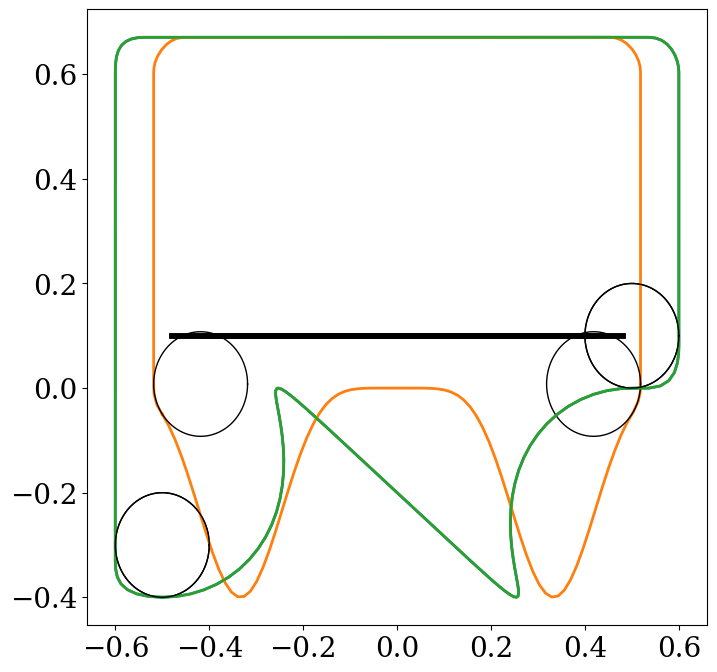

In [24]:

fmin_ls = []
fmax_ls = []
y_ls = []
xcord_ls = []
ycord_ls = []
geoms = []
for func, dfunc, ddfunc in zip([func1, func2, func3], [dfunc1, dfunc2, dfunc3], [ddfunc1, ddfunc2, ddfunc3]):
    geom = RoundedMicroGeomGenericV2(func, dfunc, ddfunc, center, height, normal, corner_w, n_refine=2)
    #geom = RoundedMicroGeomV2(func, dfunc, ddfunc, width, height, corner_w, line_pos, center_x, n_refine=2)
    #print(dr_true)
    geom.plot(plt.gca(), npts=300, show_rounded=True)
    #geom = ## 
    ## Compute deep
    print(net_settings)
    # Add features
    data_dict = geometry_to_net_input(geom, net_settings['num_pts'], output=True)
    rx_true = data_dict["rx"]
    ry_true = data_dict["ry"]
    xcord = data_dict["x"]
    ycord = data_dict["y"]
    t = data_dict["t"]
    data = unpack(lambda x: torch.from_numpy(x)[None, :])(data_dict)
    data = GeomData.tfm_inp(data)

    # Run through network
    X = concat_dict_entries(subdict(data, net_settings['input_features'])).to(net_settings['device']).to(net_settings['dtype'])
    t = _2np(data["t"])[0]
    tx, ty = _2np(data['tx'])[0], _2np(data['ty'])[0]
    dv_norm = (np.linalg.norm(_2np(data['dvt'])[0])**2 + np.linalg.norm(_2np(data['dvn'])[0])**2)**0.5 /  len(t) ** 0.5


    for i,net in enumerate(nets):
        Y = _2np(net(X))[0]

        if 'drt_norm' in net_settings['output_features']:
            # Project to cartesian
            # print("normalized output")
            rx, ry = projection(Y[0], Y[1], tx, ty, inv=True)        
            drx, dry = projection(Y[2]*dv_norm, Y[3]*dv_norm, tx, ty, inv=True)
        elif 'drx_norm' in net_settings['output_features']:
            rx, ry = Y[0], Y[1]
            drx, dry = Y[2]*dv_norm, Y[3]*dv_norm
        else:
            rx, ry = Y[0], Y[1]
            drx, dry = Y[2], Y[3]

        # Save as complex
        r = rx + 1j * ry
        dr = drx + 1j * dry
        
        if i==0:
            rxmax = rx
            rxmin = rx
            rymax = ry
            rymin = ry
        else:    
            rxmax = np.maximum(rx, rxmax)
            rxmin = np.minimum(rx, rxmin)
            rymax = np.maximum(ry, rymax)
            rymin = np.minimum(ry, rymin)


    #plt.figure(figsize=(10,4))
    #plt.plot(t_true, np.real(dr_true), 'k--')        
    #plt.plot(t_true, np.imag(dr_true), 'k--')
    #plt.fill_between(t, rxmin, rxmax, color=colors[0], alpha=0.8)
    #plt.fill_between(t, rymin, rymax, color=colors[1], alpha=0.8)

    fmax = np.concatenate([rxmax[:,None], rymax[:,None]], axis=1).T
    fmin = np.concatenate([rxmin[:,None], rymin[:,None]], axis=1).T
    y = np.concatenate([rx_true[:, None], ry_true[:, None]], axis=1).T

    fmax_ls.append(fmax)
    fmin_ls.append(fmin)
    xcord_ls.append(xcord)
    ycord_ls.append(ycord)
    y_ls.append(y)
    geoms.append(geom)
    print(y.shape, fmax.shape, fmin.shape, xcord.shape, ycord.shape)


In [25]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8,8)
matplotlib.rcParams['font.size'] = 20
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['lines.linewidth'] = 2

def add_subplot_axes(ax,rect,axisbg='w'):
    fig = plt.gcf()
    box = ax.get_position()
    width = box.width
    height = box.height
    inax_position  = ax.transAxes.transform(rect[0:2])
    transFigure = fig.transFigure.inverted()
    infig_position = transFigure.transform(inax_position)    
    x = infig_position[0]
    y = infig_position[1]
    width *= rect[2]
    height *= rect[3]  # <= Typo was here
    #subax = fig.add_axes([x,y,width,height],facecolor=facecolor)  # matplotlib 2.0+
    subax = fig.add_axes([x,y,width,height])
    x_labelsize = subax.get_xticklabels()[0].get_size()
    y_labelsize = subax.get_yticklabels()[0].get_size()
    x_labelsize *= rect[2]**0.5
    y_labelsize *= rect[3]**0.5
    subax.xaxis.set_tick_params(labelsize=x_labelsize)
    subax.yaxis.set_tick_params(labelsize=y_labelsize)
    return subax

idx0s = [-40, -20, -40]
idx1s = [-20, -10, -20]
for i, (geom, fmin, fmax, y, xcord, ycord) in enumerate(zip(geoms, fmin_ls, fmax_ls, y_ls, xcord_ls, ycord_ls)):


    ymean = np.max(y, axis=-1)

    
    fig = plt.figure(figsize=(12,6))
    ax = plt.subplot2grid((1, 3), (0, 1), colspan=2)
    plt.title("Riesz Components")
    
    labels = ["x comp", "y comp"]
    idx = [1, 0]
    for i in range(2):
        s = 1#float(1/ymean[-i])
        plt.plot(t, y[idx[i]], 'k--', label="True" if i==0 else None)
        plt.fill_between(t, fmax[idx[i]], fmin[idx[i]], color=colors[i], label=labels[i], alpha=0.5)


    idx0 = idx0s[i]
    idx1 = idx1s[i]
    tidx0, xidx0, yidx0 = t[idx0], xcord[idx0], ycord[idx0]    
    tidx1, xidx1, yidx1 = t[idx1], xcord[idx1], ycord[idx1]
    plt.fill([tidx0, tidx1, tidx1, tidx0], [ax.get_ylim()[0], ax.get_ylim()[0], ax.get_ylim()[1], ax.get_ylim()[1]], color="gray", alpha=0.4, zorder=-10)
    plt.xticks([np.pi*k for k in [0, 0.5, 1, 1.5, 2]] + [(tidx1+tidx0)/2], ["0", "$\\pi/2$", "$\\pi$", "$3\\pi/2$", "$2\\pi$", "$t_0$"])
    plt.legend(frameon=False)#, loc="upper left")
    
    ax = plt.subplot2grid((1, 3), (0, 0), colspan=1)
    hlim = -1.
    skip = 4
    xcoord_sub = xcord[::skip]
    ycoord_sub = ycord[::skip]
    rxcoord_sub = y[idx[0],::skip]
    rycoord_sub = -y[idx[1],::skip]
    rnorm = np.sqrt(rxcoord_sub**2 + rycoord_sub**2)
    #rxcoord_sub = rxcoord_sub/rnorm
    #rycoord_sub = rycoord_sub/rnorm

    print(xcord.shape, fmax.shape, rx_true.shape)
    #plt.plot(np.concatenate([xcord, xcord[0:1]]), np.concatenate([ycord, ycord[0:1]]), 'k', linewidth=2)
    geom.plot(axins, color='k', linewidth=2)
    plt.quiver(xcoord_sub, ycoord_sub, rxcoord_sub, rycoord_sub, color="k", label="True", scale=10, width=0.01)
    plt.quiver(xcoord_sub, ycoord_sub, fmax[idx[0]][::skip], -fmax[idx[1]][::skip], color="coral", label="FNO", scale=10, alpha=1, width=0.005)

    #xlim = ax.get_xlim()
    #xwid = xlim[1] - xlim[0]
    #ylim = ax.get_ylim()
    #ywid = ylim[1] - ylim[0]
    #plt.xlim(xlim[0]-xwid*0.2, xlim[1]+xwid*0.2)
    #plt.ylim(ylim[0]-ywid*0.2, ylim[1]+ywid*0.2)
    #scale=7
    #for x, y, rxmin, rymin, rxmax, rymax in zip(xcoord_sub, ycoord_sub, fmin[idx[0]][::skip], fmin[idx[1]][::skip], fmax[idx[0]][::skip], fmax[idx[1]][::skip]):
    #    x0 = (rxmax + rxmin)/2/scale
        #y0 = (rymax + rymin)/2/scale
        #plt.fill([x+rxmax/scale, x+x0, x+rxmin/scale, x+x0], [y+y0, y+rymax/scale, y+y0, y+rymin/scale], color="gray", alpha=0.5)



    plt.axis("equal")
    plt.axis("off")
    plt.legend(frameon=False, loc="lower left")
    
    
    #yheight = min(ycord) +  (max(ycord) - min(ycord))/3
    wid = (max(xcord) - min(xcord))/8
    xcenter = (xidx0 + xidx1)/2
    ycenter = (yidx0 + yidx1)/2
    xbox = (xcenter-wid/3, xcenter+wid*1.2)
    ybox = (ycenter-wid, ycenter+wid)
    #xbox = (min(xcord)-0.03*(max(xcord)-min(xcord)), min(xcord)+0.17*(max(xcord)-min(xcord)))
    #ybox = (min(ycord), min(ycord)+0.2*(max(xcord)-min(xcord)))
    #ybox = (yheight, yheight+0.2*(max(xcord)-min(xcord)))
    zoom_fac = 3
    axins = ax.inset_axes([0.25, 0.45, 0.5, 0.5], xlim=xbox, ylim=ybox, xticklabels=[], yticklabels=[])
    
    # Set grey as bg color
    axins.set_facecolor("lightgray")
    #axins.plot(np.concatenate([xcord, xcord[0:1]]), np.concatenate([ycord, ycord[0:1]]), 'k', label="True", linewidth=2*zoom_fac)
    geom.plot(axins, color='k', linewidth=2*zoom_fac)
    axins.quiver(xcoord_sub, ycoord_sub, rxcoord_sub*(ycoord_sub > hlim), rycoord_sub*(ycoord_sub > hlim), color="k", label="True", scale=10/zoom_fac, width=0.01*zoom_fac)
    axins.quiver(xcoord_sub, ycoord_sub, fmax[idx[0]][::skip], -fmax[idx[1]][::skip], color="coral", scale=10/zoom_fac, alpha=1, width=0.005*zoom_fac)

    xlim = axins.get_xlim()
    xwid = xlim[1] - xlim[0]
    ylim = axins.get_ylim()
    ywid = ylim[1] - ylim[0]
    axins.arrow(xlim[1]-xwid/2+0.05*xwid, ylim[0]+0.05*ywid, xwid/5, 0, linewidth=2, head_width=xwid/25, head_length=xwid/15, color=colors[0], alpha=0.5)
    axins.arrow(xlim[1]-xwid/2+0.05*xwid, ylim[0]+0.05*ywid, 0, xwid/5, linewidth=2, head_width=xwid/25, head_length=xwid/15, color=colors[1], alpha=0.5)
    axins.text(xlim[1]-xwid/2+0.01*xwid, ylim[0]+0.05*ywid+xwid/3.2, "$y$", fontsize=20)
    axins.text(xlim[1]-xwid/2+0.05*xwid+xwid/3.5, ylim[0]+0.03*ywid, "$x$", fontsize=20)
    #plot(axins, data_deep, data_classic)
    axins.set_xlabel("")
    axins.set_ylabel("")
    axins.set_xticks([])
    axins.set_yticks([])
    axins.set_title("$t_0$ slice")
    ax.indicate_inset_zoom(axins, edgecolor="black", facecolor="gray", alpha=0.4)

    plt.tight_layout()
    #plt.xlim(-1, 1.5)
    #plt.ylim(-0.6, 1.3)
    fig.savefig(f"{fig_dir}sample.pdf", bbox_inches="tight")





In [ ]:

data = Session.get_data(net, data_dir, device)
f, x, y, t = plot(data, nets)

ymean = np.max(np.abs(y.numpy()), axis=-1)


fig = plt.figure(figsize=(13,6))
    

#ax2 = plt.gca().twinx()  # instantiate a second axes that shares the same x-axis
for i in []:#[1,2]:#[1,2,3,4]:
    s = 1#float(1/ymean[-i])
    #s = 1/(1+(i%2))
    abserr = np.abs(y[-i] - f[0][-i])*s
    plt.fill_between(t, 0*abserr, abserr, alpha=0.2)#, color="red" if i==1 else "blue", alpha=0.2)        

    #abserr = (fmax[-i] - fmin[-i])*s
    #ax2.fill_between(t, 0*abserr, abserr, alpha=0.2)#color="red" if i==1 else "blue", alpha=0.2)        
    
#plt.plot(t, x[-1], label="x")
#    plt.plot(t, fmin[-1], label=f"min")
#plt.legend(loc="upper right", frameon=False)

    
plt.tight_layout()
fig.savefig(f"{fig_dir}sample.pdf", bbox_inches="tight")




NameError: name 'plot' is not defined

In [ ]:
print(f"rel error: {np.linalg.norm(y-f[0])/np.linalg.norm(y)}")

ftot = np.array(f)
fmax = np.max(ftot, axis=0)
fmin = np.min(ftot, axis=0)

for i in [1,2,3,4]:#[1,2,3,4]
    s = 1#float(1/ymean[-i])
    #s = 1/(1+(i%2))
    #print(s)
    plt.subplot(4,2,2*(i-1)+idx)
    if i == 4:
        plt.xticks([np.pi*k for k in [0, 0.5, 1, 1.5, 2]], ["0", "$\\pi/2$", "$\\pi$", "$3\\pi/2$", "$2\\pi$"])
    else:
        plt.xticks([])
    if idx == 2:
        plt.yticks([])
    plt.title(labels[idx-1] if i==1 else "")
    label="$v_1$, 6 sample CI" if i==1 else "$v_2$, 6 sample CI"
    plt.fill_between(t, fmax[-i]*s, fmin[-i]*s, color=colors[i-1], alpha=0.5)#color="red" if i==1 else "blue", alpha=0.5)
    plt.plot(t, y[-i]*s, 'k--')
    
    if i == 4:
        ylim = plt.gca().get_ylim()
        for j in range(4):
            plt.fill_between([0, np.pi*2], ylim[1]+1, ylim[1]+2, color=colors[j], label=f"$v_{j+1}$", alpha=0.2)
        plt.plot([0,1],  [(ylim[1]+0.1) for _ in [0, 1]], 'k--', label="True")
        #plt.fill_between([np.pi, 2*np.pi], ylim[1]+1, ylim[1]+2, color="gray", alpha=0.2)
        plt.ylim(ylim)
    
    if idx == 1 and i == 4:
        plt.legend(loc='upper center', bbox_to_anchor=(.5, -0.2), fancybox=False, shadow=False, ncol=5)
